In [355]:
import  numpy as np
import pandas as pd


In [356]:
df = pd.read_csv(r"C:\Users\rt624\OneDrive\Attachments\Desktop\spam.csv",encoding="latin-1")

In [357]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1059,spam,EASTENDERS TV Quiz. What FLOWER does DOT compa...,NaN,NaN,NaN
867,spam,PRIVATE! Your 2003 Account Statement for 07808...,NaN,NaN,NaN
5551,ham,Wen did you get so spiritual and deep. That's ...,NaN,NaN,NaN
729,ham,Dunno y u ask me.,NaN,NaN,NaN
1313,ham,How abt making some of the pics bigger?,NaN,NaN,NaN


In [358]:
df.shape

(5572, 5)

In [359]:
# 1. Data cleaning
# 2. EDA
# 3.Text preprocessing
# 4. Model building
# 5 .Model evaluation
# 6. Improvement
# 7. Website 
# 8. deploy

## 1. Data Cleaning

In [360]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [361]:
# drop last 3 columns
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [362]:
df.sample(5)

,v1,v2
4029,ham,"Cool, I'll text you in a few"
5220,ham,I have to take exam with in march 3
1186,ham,"Goodmorning, Today i am late for &lt;#&gt; min."
5024,ham,I was gonna ask you lol but i think its at 7
2823,ham,No need to buy lunch for me.. I eat maggi mee..


In [363]:
# renaming the cols
df.rename(columns={"v1":"target","v2":"text"},inplace=True)

In [364]:
df.sample(5)

,target,text
3481,spam,Do you want a NEW video phone750 anytime any n...
2674,ham,I am 6 ft. We will be a good combination!
3032,ham,"Aight, lemme know what's up"
2467,ham,Is there coming friday is leave for pongal?do ...
178,ham,Text her. If she doesnt reply let me know so i...


In [365]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [366]:
df["target"]=encoder.fit_transform(df["target"]) ## ham ko 0 value assign ho raha hai aur spam ko 1 value assign ho raha hain

In [367]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [368]:
## misiing values  
df.isnull().sum()

target    0
text      0
dtype: int64

In [369]:
## check for duplicate values
df.duplicated().sum()

np.int64(403)

In [370]:
# remove duplicated values
df = df.drop_duplicates(keep="first")

In [371]:
df.duplicated().sum()

np.int64(0)

In [372]:
df.shape

(5169, 2)

## 2. EDA

In [373]:
df.head()


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [374]:
df["target"].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

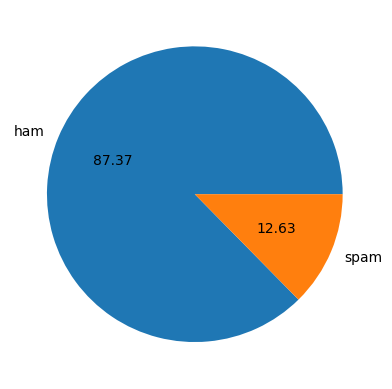

In [375]:
import matplotlib.pyplot as plt
plt.pie(df["target"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

In [376]:
## Data is imbalanced

In [377]:
import nltk

In [378]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rt624\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [379]:
df["num_characters"] = df["text"].apply(len)

In [380]:
df["num_characters"]

0       111
1        29
2       155
3        49
4        61
       ... 
5567    161
5568     37
5569     57
5570    125
5571     26
Name: num_characters, Length: 5169, dtype: int64

In [381]:
## num of words
df["text"].apply(lambda x:(nltk.word_tokenize(x))) ## har sms word by word break hokar ak list me aagya

0       [Go, until, jurong, point, ,, crazy, .., Avail...
1                [Ok, lar, ..., Joking, wif, u, oni, ...]
2       [Free, entry, in, 2, a, wkly, comp, to, win, F...
3       [U, dun, say, so, early, hor, ..., U, c, alrea...
4       [Nah, I, do, n't, think, he, goes, to, usf, ,,...
                              ...                        
5567    [This, is, the, 2nd, time, we, have, tried, 2,...
5568     [Will, Ì_, b, going, to, esplanade, fr, home, ?]
5569    [Pity, ,, *, was, in, mood, for, that, ., So, ...
5570    [The, guy, did, some, bitching, but, I, acted,...
5571                  [Rofl, ., Its, true, to, its, name]
Name: text, Length: 5169, dtype: object

In [382]:
df["num_words"] = df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [383]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [384]:
## sentence ke basis par ham apne text kp breaking kar rahe hain
df["text"].apply(lambda x:(nltk.sent_tokenize(x)))

0       [Go until jurong point, crazy.., Available onl...
1                        [Ok lar..., Joking wif u oni...]
2       [Free entry in 2 a wkly comp to win FA Cup fin...
3       [U dun say so early hor... U c already then sa...
4       [Nah I don't think he goes to usf, he lives ar...
                              ...                        
5567    [This is the 2nd time we have tried 2 contact ...
5568              [Will Ì_ b going to esplanade fr home?]
5569    [Pity, * was in mood for that., So...any other...
5570    [The guy did some bitching but I acted like i'...
5571                        [Rofl., Its true to its name]
Name: text, Length: 5169, dtype: object

In [385]:
df['num_sentences'] = df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [386]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [387]:
df[["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.460437,1.965564
std,58.236293,13.334441,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [388]:
## yeh ham message ka describe functions ka outputb hain
df[df["target"] == 0] [["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.128432,1.820195
std,56.358207,13.504730,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [389]:
## yeh spam message ka desribe  functions ka output hain
df[df["target"]==1][["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.672282,2.970904
std,30.137753,7.010932,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [390]:
## spam aur ham ke liye ham histogram plot karenge 
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

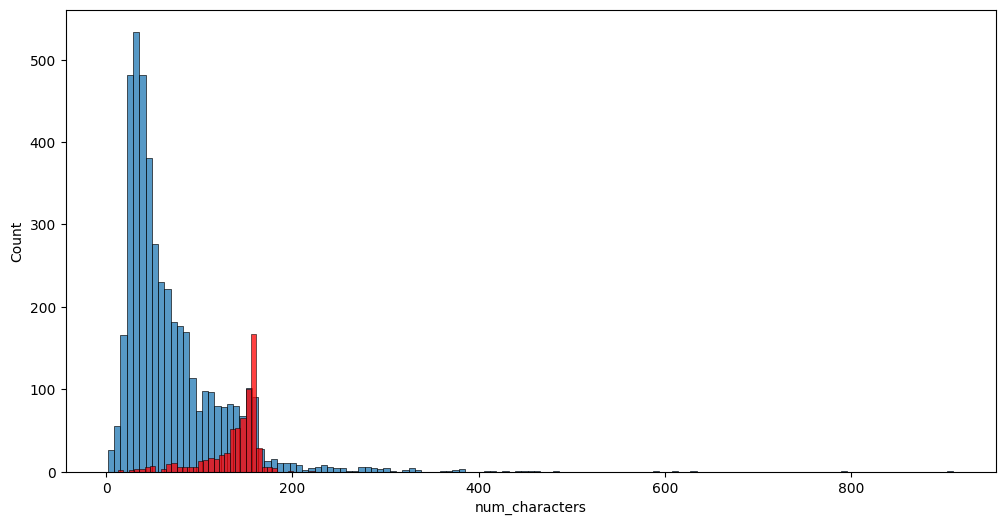

In [391]:
## number of character ke basis par ham aur spam histogram plot dekhnana
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"]==0]["num_characters"])
sns.histplot(df[df["target"]==1]["num_characters"],color="red")



<Axes: xlabel='num_words', ylabel='Count'>

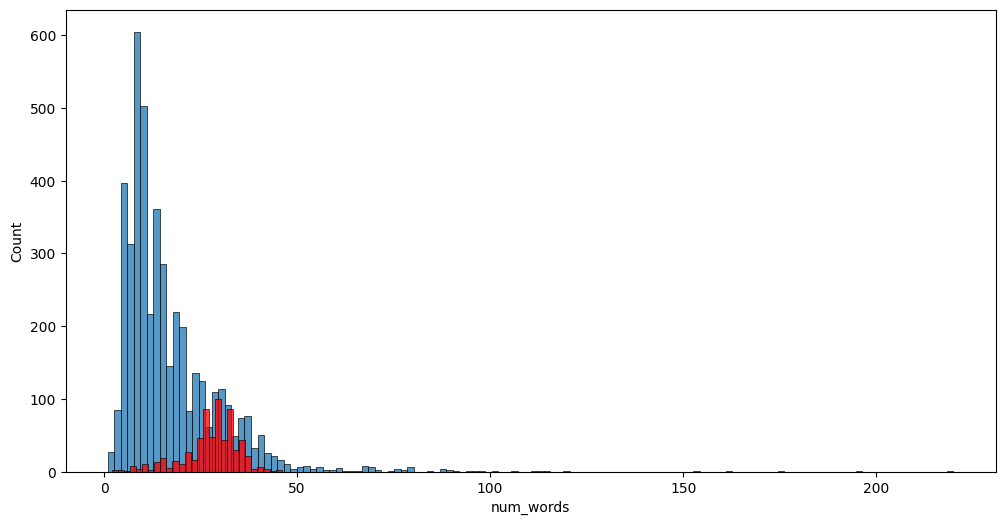

In [392]:
## number of words ke basis par ham aur spam ka histogram plot banana
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"]==0]["num_words"])
sns.histplot(df[df["target"]==1]["num_words"],color="red")

<Axes: xlabel='num_words', ylabel='Count'>

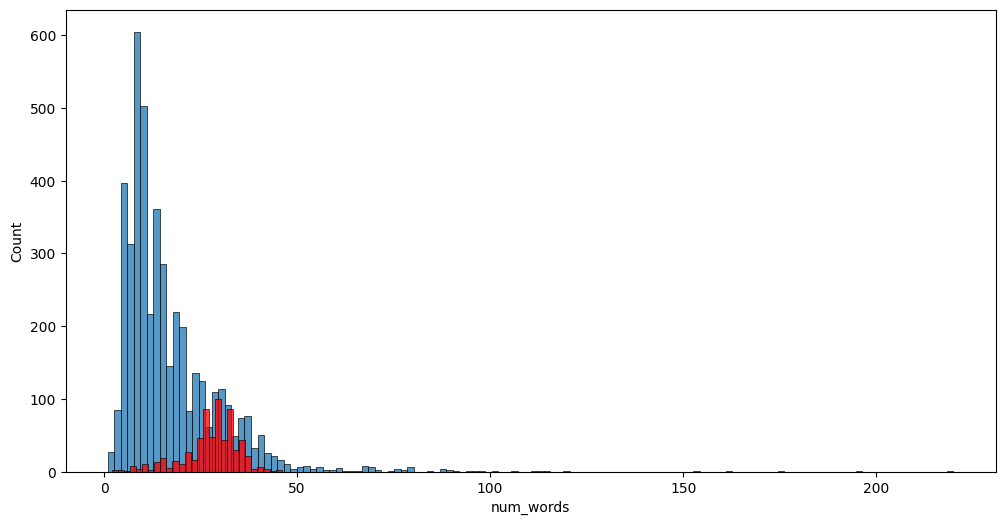

In [393]:
## number of sentences ke basis par ham aur spam histogram plot karna 
plt.figure(figsize=(12,6))
sns.histplot(df[df["target"]==0]["num_words"])
sns.histplot(df[df["target"]==1]["num_words"],color="red")

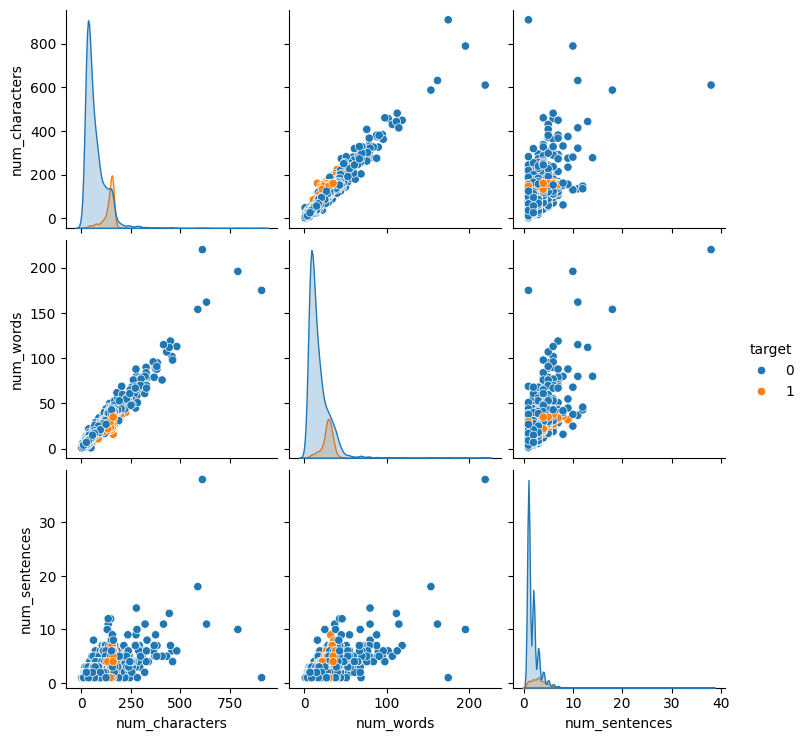

In [394]:
## all column ka target ke saath kaisa relationship hain 
sns.pairplot(df,hue="target")

<Axes: >

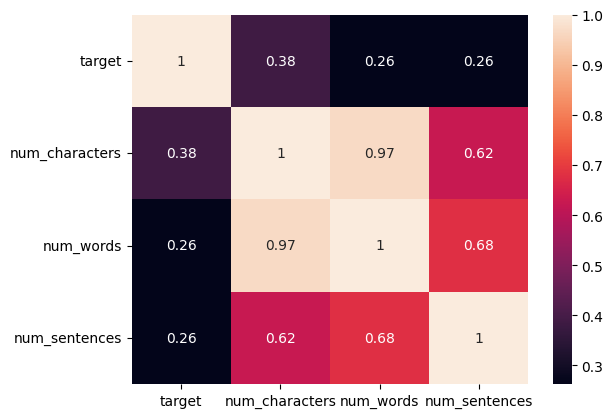

In [395]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## 3. Data Preprocessing
1. lowercase
2. tokenization
3. Removing special characters
4. Removing stop words punctuation
5. stemming

In [396]:
def transform_text(text):
    text = text.lower() ## for lower case
    text = nltk.word_tokenize(text) ## for tokenization

    y=[]

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text = y[:] 
    y.clear() 

    for i in text:
        y.append(ps.stem(i))


            

    return " ".join(y)

In [397]:
## see stopwords
from nltk.corpus import stopwords
stopwords.words("english")

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [398]:
## see punctuation
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [399]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem("loving")

'love'

In [400]:
df["text"][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [401]:
df["transfomed_text"] = df["text"].apply(transform_text)

In [402]:
df.head()

,target,text,num_characters,num_words,num_sentences,transfomed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [403]:
## ham spam aur ham text ka word cloud banayenge jo msg rahega use bada karke dikkahyega
## mostly spam message show

from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [404]:
## for spam mesaage
spam_wc = wc.generate(df[df["target"]==1]["transfomed_text"].str.cat(sep=" "))

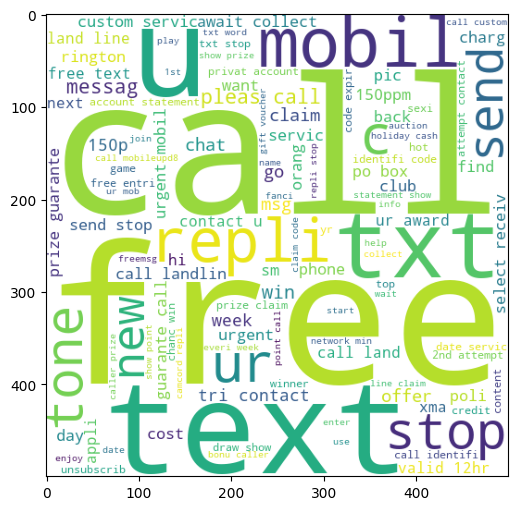

In [405]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [406]:
## for ham message
ham_wc = wc.generate(df[df["target"]==0]["transfomed_text"].str.cat(sep=" "))

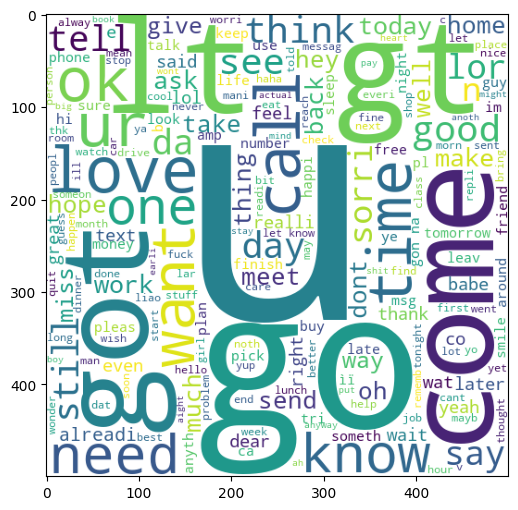

In [407]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [408]:
## top 30 words for ham and spam kaunse word mstly use kiye
df.head()

,target,text,num_characters,num_words,num_sentences,transfomed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [409]:
spam_corpus = []
for msg in df[df["target"]==1]["transfomed_text"].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [410]:
len(spam_corpus)

9942

In [411]:
## the most common spam top 30 words 
from collections import Counter
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


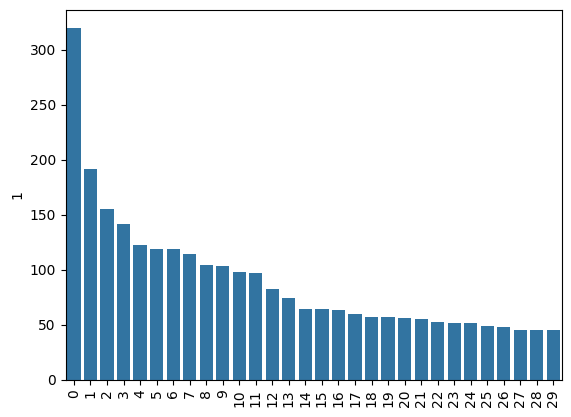

In [412]:
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation="vertical")
plt.show()

In [413]:
ham_corpus = []
for msg in df[df["target"]==0]["transfomed_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [414]:
len(ham_corpus)

35423

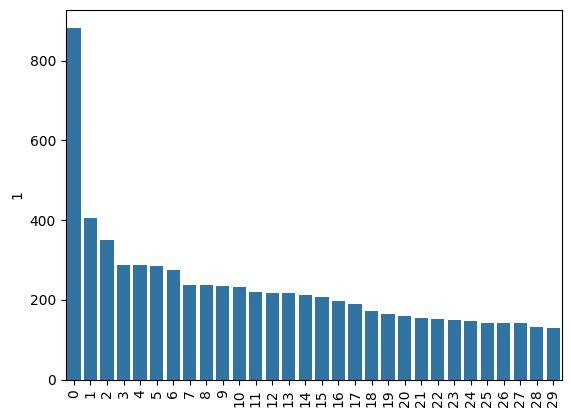

In [415]:
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation="vertical")
plt.show()

## 4. Model Building

In [416]:
## categorical columns ko numerical columns me vectorization karenge 
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)
cv = CountVectorizer(max_features=3000)

In [485]:
X = tfidf.fit_transform(df["transfomed_text"]).toarray()

In [ ]:
## scaling on independent features
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#X = scaler.fit_transform(X)

In [ ]:
## appending the num_characters col to x
#X = np.hstack((X,df["num_characters"].values.reshape(-1,1)))

In [486]:
X.shape

(5169, 3000)

In [487]:
y = df["target"].values

In [488]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [489]:
from sklearn.model_selection import train_test_split

In [490]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [491]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [492]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [493]:
gnb.fit(x_train,y_train)
y_pred1 = gnb.predict(x_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8733075435203095
[[790 106]
 [ 25 113]]
0.5159817351598174


In [494]:
mnb.fit(x_train,y_train)
y_pred2 = mnb.predict(x_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [495]:
bnb.fit(x_train,y_train)
y_pred3 = bnb.predict(x_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [429]:
## tfidf---> mnb

In [496]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [497]:
svc = SVC(kernel="sigmoid",gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver="liblinear",penalty="l1")
rfc = RandomForestClassifier(n_estimators=50,random_state=2)
abc = AdaBoostClassifier(n_estimators=50,random_state=2)
bc = BaggingClassifier(n_estimators=50,random_state=2)
etc = ExtraTreesClassifier(n_estimators=50,random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [498]:
clfs = {
    "svc":svc,
    "KN":knc,
    "NB":mnb,
    "DT":dtc,
    "LR":lrc,
    "RF":rfc,
    "Adaboost":abc
   ## "BGC":bc,
    ##"ETC":etc,
   ## "GBDT":gbdt,
   ## "XGB":xgb
}

In [499]:
def train_classifier(clf,x_train,y_train,x_test,y_test):
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [500]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [501]:
import warnings
warnings.filterwarnings("ignore")

In [502]:
accuracy_scores = []
precison_scores= []

for name,clf in clfs.items():
    current_accuracy,current_precison = train_classifier(clf,x_train,y_train,x_test,y_test)

    print("for",name)
    print("Accuracy",current_accuracy)
    print("Precison",current_precison)

    accuracy_scores.append(current_accuracy)
    precison_scores.append(current_precison)

for svc
Accuracy 0.9758220502901354
Precison 0.9747899159663865
for KN
Accuracy 0.9052224371373307
Precison 1.0
for NB
Accuracy 0.9709864603481625
Precison 1.0
for DT
Accuracy 0.9303675048355899
Precison 0.83
for LR
Accuracy 0.9555125725338491
Precison 0.96
for RF
Accuracy 0.9748549323017408
Precison 0.9827586206896551
for Adaboost
Accuracy 0.9216634429400387
Precison 0.8202247191011236


In [503]:
performance_df = pd.DataFrame({"Algorithm":clfs.keys(),"Accuracy":accuracy_scores,"Precison":precison_scores}).sort_values("Precison",ascending=False)

In [504]:
performance_df

,Algorithm,Accuracy,Precison
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.974855,0.982759
0,svc,0.975822,0.974790
4,LR,0.955513,0.960000
3,DT,0.930368,0.830000
6,Adaboost,0.921663,0.820225


In [505]:
performance_df1 = pd.melt(performance_df,id_vars="Algorithm")

In [506]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.974855
3,svc,Accuracy,0.975822
4,LR,Accuracy,0.955513
5,DT,Accuracy,0.930368
6,Adaboost,Accuracy,0.921663
7,KN,Precison,1.000000
8,NB,Precison,1.000000
9,RF,Precison,0.982759


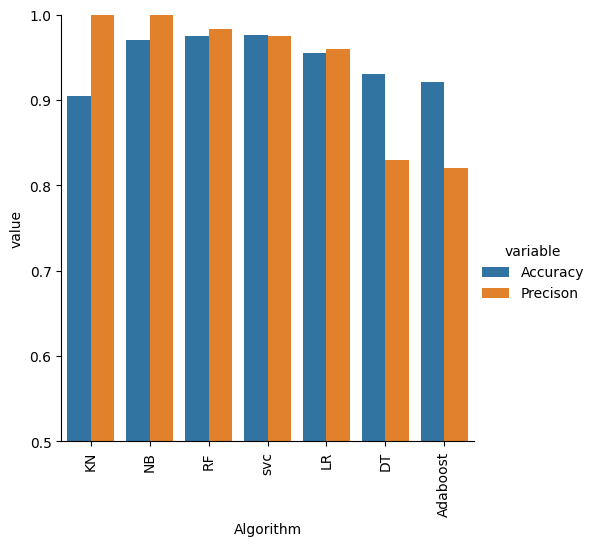

In [507]:
sns.catplot(x="Algorithm",y="value",hue="variable",data=performance_df1,kind="bar",height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation="vertical")
plt.show()

## model improve

In [442]:
## model improve
# 1. change the max_features parameters of tfidf

In [508]:
temp_df = pd.DataFrame({"Algorithm":clfs.keys(),"Acuuracy_score_3000":accuracy_scores,"precison_scores_3000":precison_scores})

In [509]:
new_df = performance_df.merge(temp_df,on="Algorithm")


In [510]:
new_df

,Algorithm,Accuracy,Precison,Acuuracy_score_3000,precison_scores_3000
0,KN,0.905222,1.000000,0.905222,1.000000
1,NB,0.970986,1.000000,0.970986,1.000000
2,RF,0.974855,0.982759,0.974855,0.982759
3,svc,0.975822,0.974790,0.975822,0.974790
4,LR,0.955513,0.960000,0.955513,0.960000
5,DT,0.930368,0.830000,0.930368,0.830000
6,Adaboost,0.921663,0.820225,0.921663,0.820225


In [511]:
import pickle
pickle.dump(tfidf,open("vectorizer.pkl","wb"))
pickle.dump(mnb,open("model.pkl","wb"))